In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import joblib

print("⏳ 1. Đang khởi tạo bộ dữ liệu học tập mẫu...")
np.random.seed(42)
n_samples = 2000

study_hours = np.random.uniform(1, 12, n_samples)
focus_score = np.random.uniform(20, 100, n_samples)
assignments = np.random.uniform(30, 100, n_samples)
attendance = np.random.uniform(50, 100, n_samples)
phone_hours = np.random.uniform(1, 10, n_samples)
stress_level = np.random.uniform(1, 10, n_samples)
sleep_hours = np.random.uniform(4, 9, n_samples)

base_score = (33.2 + (study_hours * 4.3) + (focus_score * 0.28) + 
              ((assignments / 100) * 25 * 0.4) + (attendance * 0.08) - 
              (phone_hours * 2.1) - (stress_level * 1.3) + (sleep_hours * 0.7))
final_grade = np.clip(base_score + np.random.normal(0, 2, n_samples), 15, 99.9)

# Tạo bảng dữ liệu và TỰ ĐỘNG LƯU THÀNH FILE train.csv
df = pd.DataFrame({
    'study_hours': study_hours, 'focus_score': focus_score, 'assignments': assignments,
    'attendance': attendance, 'phone_hours': phone_hours, 'stress_level': stress_level, 'sleep_hours': sleep_hours,
    'final_grade': final_grade
})

# Đổi tên file lưu trữ tại đây sang train.csv
df.to_csv('train.csv', index=False)
print("✅ Đã tự động tạo và lưu file 'train.csv' vào thư mục dự án!")

# 2. Chia dữ liệu & Train Model
X = df.drop(columns=['final_grade'])
y = df['final_grade']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("🤖 2. Đang huấn luyện Model bằng Random Forest...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f"📊 Độ chính xác của Model: {model.score(X_test, y_test) * 100:.2f}%")

# 3. Xuất file model mã hóa thành student_model.pkl để backend app.py sử dụng
joblib.dump(model, 'student_model.pkl')
print("💾 Xuất file bộ não AI thành công: 'student_model.pkl'")

⏳ 1. Đang khởi tạo bộ dữ liệu học tập mẫu...
✅ Đã tự động tạo và lưu file 'train.csv' vào thư mục dự án!
🤖 2. Đang huấn luyện Model bằng Random Forest...
📊 Độ chính xác của Model: 95.18%
💾 Xuất file bộ não AI thành công: 'student_model.pkl'


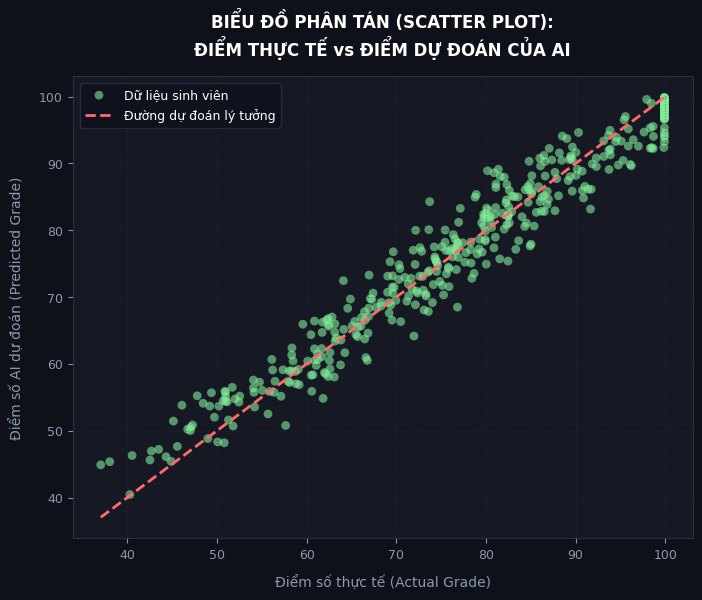

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dùng model AI đã huấn luyện để dự đoán trên tập kiểm tra (X_test)
y_pred = model.predict(X_test)

# 2. Cấu hình giao diện biểu đồ Scatter Plot (Tone màu tối Cyberpunk cho hợp với Web của bạn)
plt.figure(figsize=(8, 6), facecolor='#0e101a')
ax = plt.axes()
ax.set_facecolor('#161924')

# Vẽ các điểm phân tán (Scatter) giữa Điểm Thực tế và Điểm Dự đoán
plt.scatter(y_test, y_pred, color='#80ED99', alpha=0.6, edgecolors='none', s=40, label='Dữ liệu sinh viên')

# Vẽ một đường thẳng chéo hoàn hảo (Nếu điểm nằm trên đường này là dự đoán đúng 100%)
perfect_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(perfect_line, perfect_line, color='#FF6B6B', linestyle='--', linewidth=2, label='Đường dự đoán lý tưởng')

# Định dạng tiêu đề và các trục tọa độ
plt.title('BIỂU ĐỒ PHÂN TÁN (SCATTER PLOT):\nĐIỂM THỰC TẾ vs ĐIỂM DỰ ĐOÁN CỦA AI', 
          color='#FFFFFF', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Điểm số thực tế (Actual Grade)', color='#8A99AD', fontsize=10, labelpad=10)
plt.ylabel('Điểm số AI dự đoán (Predicted Grade)', color='#8A99AD', fontsize=10, labelpad=10)

# Chỉnh màu chữ cho các số trên trục tọa độ
ax.tick_params(colors='#8A99AD', labelsize=9)
for spine in ax.spines.values():
    spine.set_color('#2A3047')

# Hiển thị chú thích (Legend)
legend = plt.legend(facecolor='#0e101a', edgecolor='#2A3047')
for text in legend.get_texts():
    text.set_color('#FFFFFF')
    text.set_fontsize(9)

plt.grid(True, color='#2A3047', linestyle=':', alpha=0.5)

# Hiển thị biểu đồ ngay trong Jupyter Notebook
plt.show()

============ KẾT QUẢ MÔ HÌNH HỒI QUY TUYẾN TÍNH ============
📌 Hệ số chặn (Intercept): 35.5292

📌 Hệ số góc của các chỉ số hành vi (Coefficients):
   - study_hours: +4.0980
   - focus_score: +0.2567
   - assignments: +0.0893
   - attendance: +0.0749
   - phone_hours: -1.9373
   - stress_level: -1.1664
   - sleep_hours: +0.5956



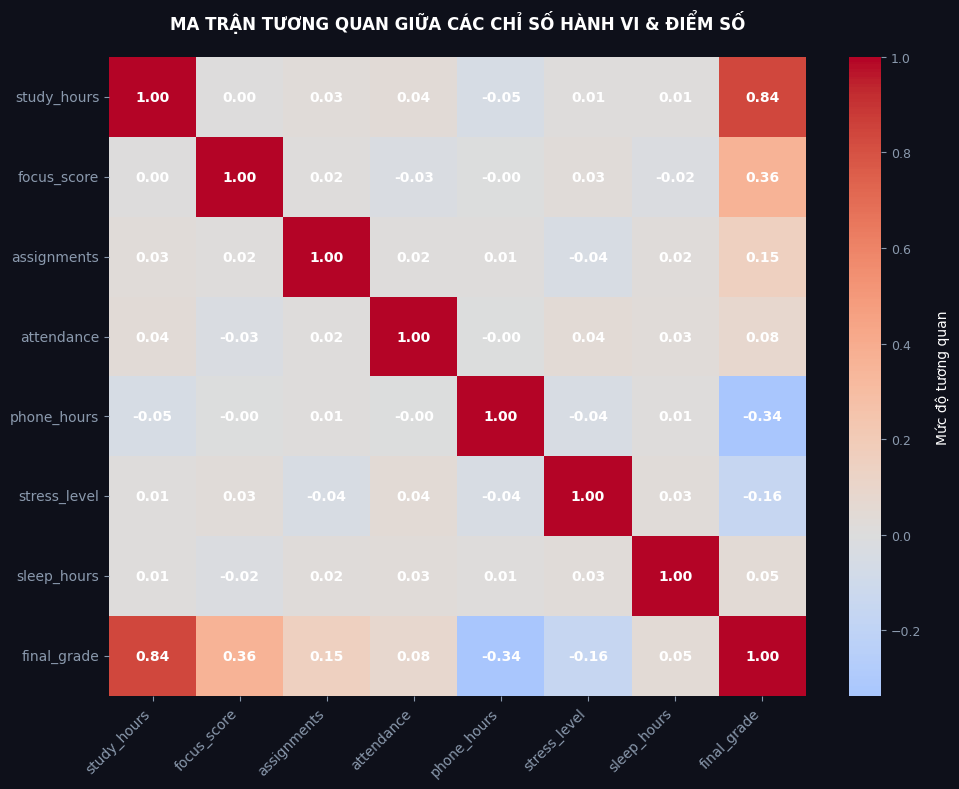

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Giả định dữ liệu df (train.csv) đã có từ ô code trước
# 1. CHẠY MÔ HÌNH LINEAR REGRESSION LẤY HỆ SỐ
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("============ KẾT QUẢ MÔ HÌNH HỒI QUY TUYẾN TÍNH ============")
print(f"📌 Hệ số chặn (Intercept): {lr_model.intercept_:.4f}\n")
print("📌 Hệ số góc của các chỉ số hành vi (Coefficients):")

# Ghép tên cột với hệ số tương ứng để nhìn cho rõ
for col, coef in zip(X.columns, lr_model.coef_):
    print(f"   - {col}: {coef:+.4f}")
print("===========================================================\n")


# 2. VẼ BẢNG CORRELATION (HEATMAP TƯƠNG QUAN)
plt.figure(figsize=(10, 8), facecolor='#0e101a')
ax = plt.axes()
ax.set_facecolor('#161924')

# Tính toán ma trận tương quan từ file train.csv
corr_matrix = df.corr()

# Vẽ biểu đồ nhiệt (Heatmap) với tone màu phù hợp giao diện Optime
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 10, "weight": "bold", "color": "white"},
            cbar_kws={'label': 'Mức độ tương quan'}, ax=ax)

# Định dạng chữ nghĩa trên biểu đồ
plt.title('MA TRẬN TƯƠNG QUAN GIỮA CÁC CHỈ SỐ HÀNH VI & ĐIỂM SỐ', 
          color='#FFFFFF', fontsize=12, fontweight='bold', pad=20)
ax.tick_params(colors='#8A99AD', labelsize=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Chỉnh màu cho thanh thước đo (Colorbar)
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#8A99AD')
cbar.ax.set_ylabel('Mức độ tương quan', color='#FFFFFF', fontsize=10, labelpad=10)
cbar.ax.tick_params(labelsize=9, colors='#8A99AD')

plt.tight_layout()
plt.show()